# 3. Custom pupil + Zernike DM (VAMPIRES)

Wraps an external pupil-generation function (`miles_pupil`) via the `external_pupil` aperture, and drives a Zernike-mode deformable mirror. The fixture config reproduces the 2023-10 VAMPIRES base setup against the captured digest.

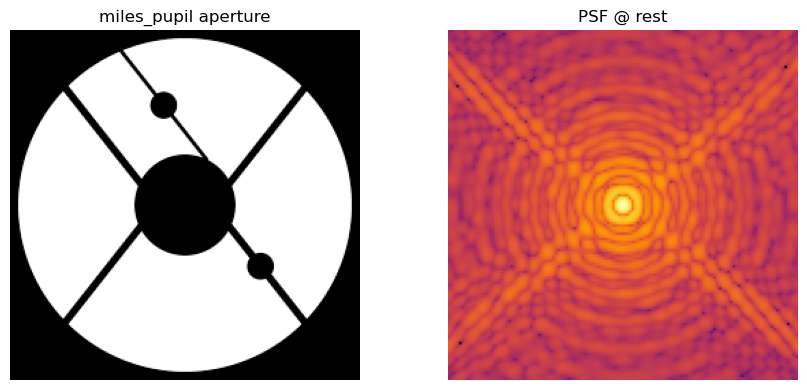

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from telescope_sim import TelescopeSim

sim = TelescopeSim.from_yaml("fixtures/configs/09_vampires_base.yaml")
out = sim.sample()
psf = out["images"]["psf"][..., 0]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(sim.aperture.field.shaped, cmap="Greys_r")
axes[0].set_title("miles_pupil aperture")
axes[0].set_axis_off()
axes[1].imshow(np.log10(psf + 1e-10), cmap="inferno")
axes[1].set_title("PSF @ rest")
axes[1].set_axis_off()
plt.tight_layout()
plt.show()


Push a few Zernike modes and see the focal plane respond.

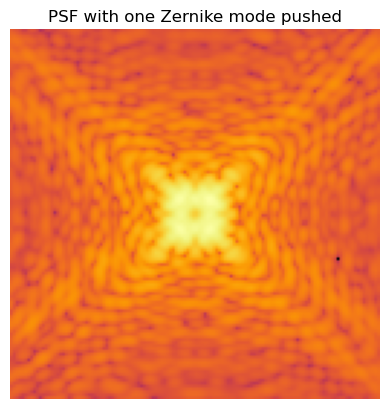

In [2]:
amps = np.zeros(10)
amps[3] = 0.3   # one of the low-order modes
out = sim.sample(actuations={"zernike_dm": amps})
plt.imshow(np.log10(out["images"]["psf"][..., 0] + 1e-10), cmap="inferno")
plt.title("PSF with one Zernike mode pushed")
plt.axis("off")
plt.show()
